In [1]:
import gensn
import gensn.distributions as G
import torch
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from task_transfer.routines import mc_marginal_log_likelihood

seed = 1123
torch.manual_seed(seed)
rng = default_rng(seed)

# Define number of neurons and dimensionality of images

In [2]:
n_neurons = 2
n_image_dims = 3

# Define the ground truth brain generative model for each task 1 and task 2

In [3]:
t1_prior_mean = torch.tensor([2., -1.])
t1_prior_cov = torch.rand((n_neurons, n_neurons))
t1_prior_cov = t1_prior_cov @ t1_prior_cov.T + torch.finfo(t1_prior_cov.dtype).eps * torch.eye(
    n_neurons
)
t1_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t1_prior_mean, covariance_matrix=t1_prior_cov
)

In [4]:
t2_prior_mean = torch.tensor([-2., 2.])
t2_prior_cov = torch.rand((n_neurons, n_neurons))
t2_prior_cov = t2_prior_cov @ t2_prior_cov.T + torch.finfo(
    t2_prior_cov.dtype
).eps * torch.eye(n_neurons)
t2_prior_cov = -t2_prior_cov * -torch.eye(n_neurons)
t2_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t2_prior_mean, covariance_matrix=t2_prior_cov
)

/tmp/ipykernel_3430658/4072691499.py:9: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")


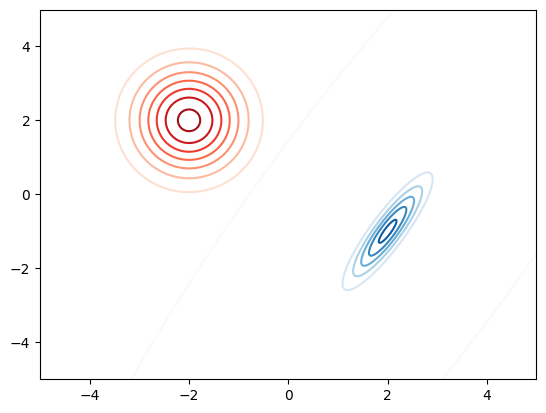

In [5]:
x, y = np.mgrid[-5:5:.01, -5:5:.01]
pos = np.dstack((x, y))

t1_pdf = t1_prior(torch.tensor(pos)).exp()
t2_pdf = t2_prior(torch.tensor(pos)).exp()

fig, ax = plt.subplots(dpi=100)
ax.contour(x, y, t1_pdf, cmap="Blues")
ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")

In [6]:
likelihood_fn = torch.nn.Linear(n_neurons, n_image_dims)
likelihood_fn.weight.data = torch.rand(n_image_dims, n_neurons)
likelihood_fn.bias.data = torch.rand(n_image_dims)
conditional_cov = torch.rand((n_image_dims, n_image_dims))
conditional_cov = conditional_cov @ conditional_cov.T + torch.finfo(
    conditional_cov.dtype
).eps * torch.eye(n_image_dims)
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)

t1_joint = G.Joint(prior=t1_prior, conditional=conditional)
t2_joint = G.Joint(prior=t2_prior, conditional=conditional)

In [7]:
t1_marginal_mean = likelihood_fn(t1_prior_mean)
t1_marginal_cov = conditional_cov + likelihood_fn.weight.data @ t1_prior_cov @ likelihood_fn.weight.data.T
t1_marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t1_marginal_mean, covariance_matrix=t1_marginal_cov
)

t2_marginal_mean = likelihood_fn(t2_prior_mean)
t2_marginal_cov = conditional_cov + likelihood_fn.weight.data @ t2_prior_cov @ likelihood_fn.weight.data.T
t2_marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t2_marginal_mean, covariance_matrix=t2_marginal_cov
)

In [8]:
# x, y = np.mgrid[-2:5:0.01, -2:5:0.01]
# pos = np.dstack((x, y))

# t1_marginal_pdf = t1_marginal(torch.tensor(pos)).exp().detach()
# t2_marginal_pdf = t2_marginal(torch.tensor(pos)).exp().detach()

# fig, ax = plt.subplots(dpi=100)
# ax.contourf(x, y, t1_marginal_pdf, cmap="Blues")
# ax.contourf(x, y, t2_marginal_pdf, cmap="Reds", alpha=0.5)

# Create datasets

In [9]:
dataset_size = 10_000
t1_responses, t1_images = t1_joint.sample((dataset_size,))
t2_responses, t2_images = t2_joint.sample((dataset_size,))

In [10]:
t1_train_responses = t1_responses[:int(dataset_size * 0.8)]
t1_train_images = t1_images[:int(dataset_size * 0.8)]
t1_test_responses = t1_responses[int(dataset_size * 0.8):]
t1_test_images = t1_images[int(dataset_size * 0.8):]

# Learning sampling model

## Learn the generative model under t1
Parameters to learn: A, b, t1_mu, t1_cov

In [11]:
def lstsq_solution(Y, X):
    design_matrix = torch.cat(
        [X, torch.ones_like(X[:, :1])], dim=1
    )
    solution = (
        torch.inverse(design_matrix.T @ design_matrix)
        @ design_matrix.T
        @ Y
    )
    A = solution[:-1]
    b = solution[-1]
    return A, b

In [12]:
learned_A, learned_b = lstsq_solution(t1_train_images, t1_train_responses)
learned_likelihood_fn = torch.nn.Linear(n_image_dims, n_neurons)
learned_likelihood_fn.weight.data = learned_A.T
learned_likelihood_fn.bias.data = learned_b
learned_t1_conditional_cov = torch.cov((t1_train_images - t1_train_responses @ learned_A - learned_b).T)
learned_t1_prior_mean = t1_train_responses.mean(dim=0)
learned_t1_prior_cov = t1_train_responses.T.cov()

In [13]:
learned_t1_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=learned_t1_prior_mean, covariance_matrix=learned_t1_prior_cov
)
learned_t1_conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=learned_likelihood_fn, covariance_matrix=learned_t1_conditional_cov
)
learned_t1_joint = G.Joint(prior=learned_t1_prior, conditional=learned_t1_conditional)

## Invert generative model to get posterior distribution, used as predictive model

In [14]:
def gaussian_posterior(prior, conditional):
    prior_mean = prior.distribution().loc
    prior_cov = prior.distribution().covariance_matrix
    A = conditional.loc.weight.data
    b = conditional.loc.bias.data
    noise_cov = conditional.covariance_matrix
    posterior_cov = torch.inverse(
        torch.inverse(prior_cov) + A.T @ torch.inverse(noise_cov) @ A
    )
    M = posterior_cov @ A.T @ torch.inverse(noise_cov)
    C = posterior_cov @ torch.inverse(prior_cov) @ prior_mean - M @ b
    likelihood_fn = torch.nn.Linear(n_neurons, n_image_dims)
    likelihood_fn.weight.data = M
    likelihood_fn.bias.data = C
    posterior = G.TrainableDistributionAdapter(
        D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=posterior_cov
    )
    return posterior

In [15]:
true_t1_posterior = gaussian_posterior(t1_prior, conditional)
learned_t1_posterior = gaussian_posterior(learned_t1_joint.prior, learned_t1_joint.conditional)

# Learn sysident model via train samples

In [16]:
def sysident_posterior(train_responses, train_images):
    M, C = lstsq_solution(train_responses, train_images)
    sysident_fn = torch.nn.Linear(train_responses.shape[-1], train_images.shape[-1])
    sysident_fn.weight.data = M.T
    sysident_fn.bias.data = C
    sysident_posterior_cov = torch.cov(
        (train_responses - train_images @ M - C).T
    )
    return G.TrainableDistributionAdapter(
        D.MultivariateNormal, loc=sysident_fn, covariance_matrix=sysident_posterior_cov
    )

In [17]:
learned_sysident_posterior = sysident_posterior(t1_train_responses, t1_train_images)

# Evaluate the models on test samples

In [18]:
with torch.no_grad():
    true_t1_ll = true_t1_posterior(t1_train_responses, cond=t1_train_images)
    learned_t1_ll = learned_t1_posterior(t1_train_responses, cond=t1_train_images)
    sysident_t1_ll = learned_sysident_posterior(t1_train_responses, cond=t1_train_images)

In [19]:
true_t1_ll_mean = true_t1_ll.mean()
true_t1_ll_se = true_t1_ll.std() / np.sqrt(len(true_t1_ll))
learned_t1_ll_mean = learned_t1_ll.mean()
learned_t1_ll_se = learned_t1_ll.std() / np.sqrt(len(learned_t1_ll))
sysident_t1_ll_mean = sysident_t1_ll.mean()
sysident_t1_ll_se = sysident_t1_ll.std() / np.sqrt(len(sysident_t1_ll))

In [20]:
true_t1_ll.shape, learned_t1_ll.shape, sysident_t1_ll.shape

(torch.Size([8000]), torch.Size([8000]), torch.Size([8000]))

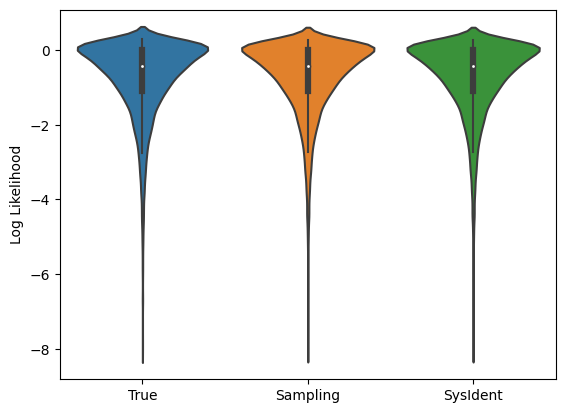

In [21]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(data=[true_t1_ll, learned_t1_ll, sysident_t1_ll], ax=ax)
ax.set_xticklabels(["True", "Sampling", "SysIdent"])
ax.set_ylabel("Log Likelihood")
plt.show()


In [22]:
true_t1_ll.mean(), learned_t1_ll.mean(), sysident_t1_ll.mean()

(tensor(-0.7227), tensor(-0.7214), tensor(-0.7214))

In [23]:
with torch.no_grad():
    true_t1_ll_test = true_t1_posterior(t1_test_responses, cond=t1_test_images)
    learned_t1_ll_test = learned_t1_posterior(t1_test_responses, cond=t1_test_images)
    sysident_t1_ll_test = learned_sysident_posterior(t1_test_responses, cond=t1_test_images)

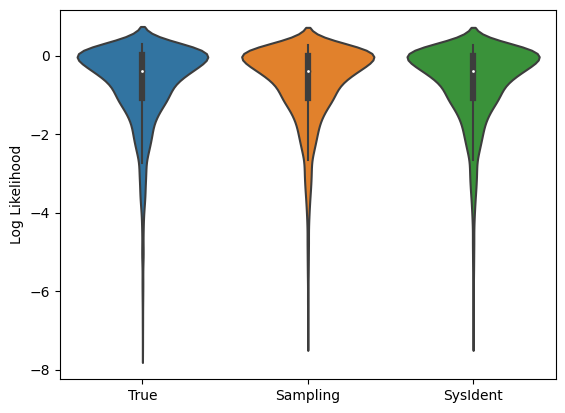

In [24]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(data=[true_t1_ll_test, learned_t1_ll_test, sysident_t1_ll_test], ax=ax)
ax.set_xticklabels(["True", "Sampling", "SysIdent"])
ax.set_ylabel("Log Likelihood")
plt.show()

In [25]:
true_t1_ll_test.mean(), learned_t1_ll_test.mean(), sysident_t1_ll_test.mean()

(tensor(-0.7055), tensor(-0.7077), tensor(-0.7077))

# Now change the prior, adapt the learned generative model to the new prior and evaluate the models on test samples

## First evaluate models on new task samples

In [26]:
t2_train_responses = t2_responses[: int(dataset_size * 0.8)]
t2_train_images = t2_images[: int(dataset_size * 0.8)]
t2_test_responses = t2_responses[int(dataset_size * 0.8) :]
t2_test_images = t2_images[int(dataset_size * 0.8) :]

In [27]:
true_t2_posterior = gaussian_posterior(t2_prior, conditional)

In [28]:
with torch.no_grad():
    true_t2_ll = true_t2_posterior(t2_train_responses, cond=t2_train_images)

In [29]:
true_t2_ll.mean()

tensor(-1.8843)

In [30]:
with torch.no_grad():
    true_t2_ll_test = true_t2_posterior(t2_test_responses, cond=t2_test_images)

In [31]:
true_t2_ll_test.mean()

tensor(-1.9210)

In [32]:
with torch.no_grad():
    old_learned_t2_ll = learned_t1_posterior(t2_train_responses, cond=t2_train_images)
    old_learned_t2_ll_test = learned_t1_posterior(t2_test_responses, cond=t2_test_images)
    old_sysident_t2_ll = learned_sysident_posterior(t2_train_responses, cond=t2_train_images)
    old_sysident_t2_ll_test = learned_sysident_posterior(t2_test_responses, cond=t2_test_images)

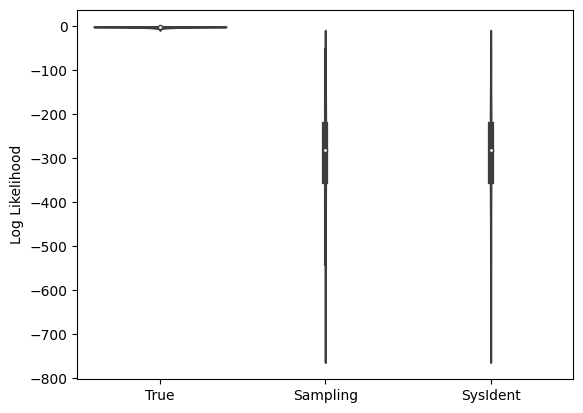

In [33]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(
    data=[true_t2_ll_test, old_learned_t2_ll_test, old_sysident_t2_ll_test], ax=ax
)
ax.set_xticklabels(["True", "Sampling", "SysIdent"])
ax.set_ylabel("Log Likelihood")
plt.show()

In [34]:
old_learned_t2_ll.mean(), old_learned_t2_ll_test.mean(), old_sysident_t2_ll.mean(), old_sysident_t2_ll_test.mean()

(tensor(-290.5220), tensor(-291.0081), tensor(-290.5221), tensor(-291.0082))

## Now adapt the generative model to the new task

In [35]:
adapted_prior_mean = torch.nn.Parameter((torch.randn_like(t1_prior_mean)))
adapted_prior_cov = gensn.parameters.Covariance(n_dims=n_neurons)
adapted_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=adapted_prior_mean, covariance_matrix=adapted_prior_cov
)

# adapted_likelihood_fn = likelihood_fn
# adapted_conditional_cov = conditional_cov
# adapted_conditional = G.TrainableDistributionAdapter(
#     D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
# )
adapted_joint = G.Joint(prior=adapted_prior, conditional=conditional)

In [36]:
# create a pytorch dataloader with the observed samples
train_dataloader = DataLoader(
    TensorDataset(t2_train_images), batch_size=128, shuffle=True
)
test_dataloader = DataLoader(
    TensorDataset(t2_test_images), batch_size=128, shuffle=False
)

In [37]:
lr = 1e-3
optimizer = Adam(adapted_joint.prior.parameters(), lr=lr)
n_epochs = 200
train_losses = []
mc_sample_size = (100,)
for epoch in range(n_epochs):
    total_loss = 0
    for obs_batch in train_dataloader:
        optimizer.zero_grad()
        obs = obs_batch[0]
        loss = -mc_marginal_log_likelihood(adapted_joint, obs, mc_sample_size, "mean")
        # loss = -joint.log_prob(obs_batch).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch} Loss: {mean_loss}")
    train_losses.append(mean_loss)

with torch.no_grad():
    test_losses = []
    for obs_batch in test_dataloader:
        obs = obs_batch[0]
        test_loss = -mc_marginal_log_likelihood(adapted_joint, obs, mc_sample_size, "mean")
        test_losses.append(test_loss)
    mean_test_loss = np.mean(test_losses)

Epoch 0 Loss: 3.664119565297687
Epoch 1 Loss: 3.6258957348172625
Epoch 2 Loss: 3.5954038037194147
Epoch 3 Loss: 3.5529988304017084
Epoch 4 Loss: 3.5498028028578985
Epoch 5 Loss: 3.510042190551758
Epoch 6 Loss: 3.5000487925514343
Epoch 7 Loss: 3.4710499710506864
Epoch 8 Loss: 3.454706067130679
Epoch 9 Loss: 3.4381397111075267
Epoch 10 Loss: 3.403433262355744
Epoch 11 Loss: 3.3885759209829662
Epoch 12 Loss: 3.375455969855899
Epoch 13 Loss: 3.3635746108161078
Epoch 14 Loss: 3.341360587922354
Epoch 15 Loss: 3.333745313069177
Epoch 16 Loss: 3.322035895453559
Epoch 17 Loss: 3.31268408563402
Epoch 18 Loss: 3.2892137595585416
Epoch 19 Loss: 3.2835017083183167
Epoch 20 Loss: 3.26789789351206
Epoch 21 Loss: 3.2665727630494135
Epoch 22 Loss: 3.2595610997033497
Epoch 23 Loss: 3.250352587018694
Epoch 24 Loss: 3.2495266634320457
Epoch 25 Loss: 3.245724628842066
Epoch 26 Loss: 3.244592799080743
Epoch 27 Loss: 3.236025337188963
Epoch 28 Loss: 3.233567237854004
Epoch 29 Loss: 3.230731381310357
Epoch 30

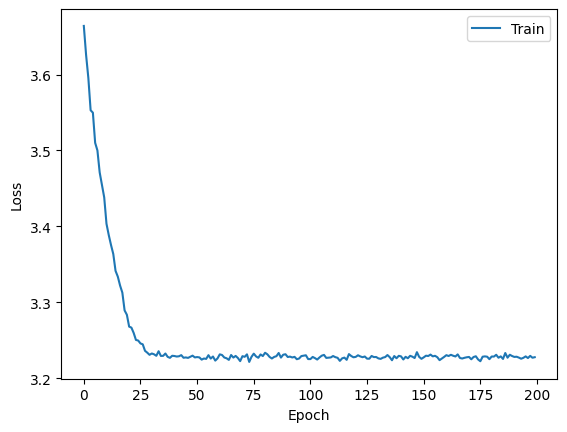

In [38]:
# plot the train and test losses
fig, ax = plt.subplots(dpi=100)
ax.plot(train_losses, label="Train")
# ax.plot(test_losses, color="red", label="Test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

In [39]:
t2_prior

TrainableDistributionAdapter(
  distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([-2.,  2.]), covariance_matrix=tensor([[0.5546, 0.0000],
          [0.0000, 0.9458]])
)

In [40]:
adapted_prior.loc

Parameter containing:
tensor([-1.9936,  2.0331], requires_grad=True)

In [41]:
adapted_prior.covariance_matrix()

tensor([[0.5345, 0.0634],
        [0.0634, 0.8582]], grad_fn=<AddBackward0>)

In [42]:
adapted_posterior = gaussian_posterior(adapted_prior, conditional)

In [43]:
with torch.no_grad():
    adapted_t2_ll = adapted_posterior(t2_train_responses, cond=t2_train_images)
    adapted_t2_ll_test = adapted_posterior(
        t2_test_responses, cond=t2_test_images
    )

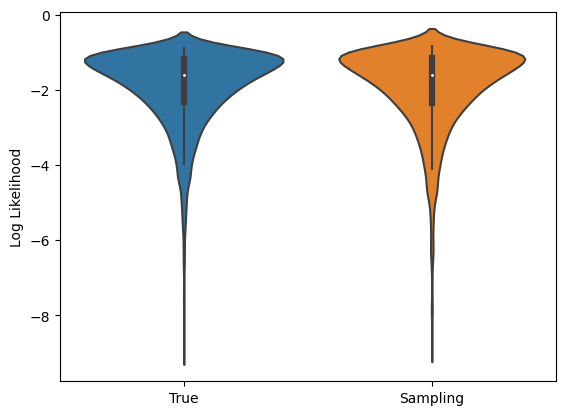

In [44]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(
    data=[true_t2_ll_test, adapted_t2_ll_test], ax=ax
)
ax.set_xticklabels(["True", "Sampling"])
ax.set_ylabel("Log Likelihood")
plt.show()

In [45]:
training_size_proportions= np.linspace(0.1, 1, 10)
t2_learned_sysident_posteriors = []
for prop in training_size_proportions:
    t2_train_images = t2_images[:int(dataset_size * prop)]
    t2_train_responses = t2_responses[:int(dataset_size * prop)]
    t2_learned_sysident_posteriors.append(sysident_posterior(t2_train_responses, t2_train_images))

In [46]:
t2_sysident_posterior_test_lls = []
for posterior in t2_learned_sysident_posteriors:
    with torch.no_grad():
        t2_sysident_posterior_test_lls.append(posterior(t2_test_responses, cond=t2_test_images))

In [47]:
for ll in t2_sysident_posterior_test_lls:
    print(ll.mean())

tensor(-1.9265)
tensor(-1.9214)
tensor(-1.9205)
tensor(-1.9210)
tensor(-1.9211)
tensor(-1.9215)
tensor(-1.9211)
tensor(-1.9209)
tensor(-1.9206)
tensor(-1.9200)


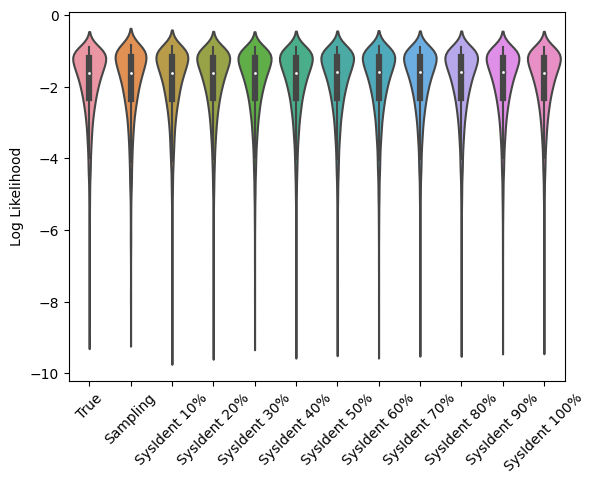

In [48]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(data=[true_t2_ll_test, adapted_t2_ll_test, *t2_sysident_posterior_test_lls], ax=ax)
ax.set_xticklabels(["True", "Sampling"] + [f"SysIdent {prop:.0%}" for prop in training_size_proportions], rotation=45)
ax.set_ylabel("Log Likelihood")
plt.show()

In [49]:
training_size_proportions

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [50]:
t2_sysident_posterior_test_ll_means = [ll.mean() for ll in t2_sysident_posterior_test_lls]

In [51]:
len(t2_sysident_posterior_test_ll_means)

10

In [52]:
adapted_t2_ll_test.mean()

tensor(-1.9322)

In [53]:
[
    true_t2_ll_test.mean(),
    adapted_t2_ll_test.mean(),
    *t2_sysident_posterior_test_ll_means,
]

[tensor(-1.9210),
 tensor(-1.9322),
 tensor(-1.9265),
 tensor(-1.9214),
 tensor(-1.9205),
 tensor(-1.9210),
 tensor(-1.9211),
 tensor(-1.9215),
 tensor(-1.9211),
 tensor(-1.9209),
 tensor(-1.9206),
 tensor(-1.9200)]

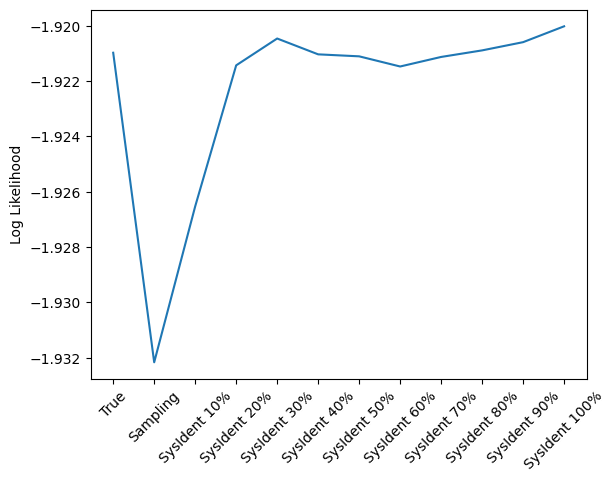

In [54]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
# sns.violinplot(
#     data=[true_t2_ll_test, adapted_t2_ll_test, *t2_sysident_posterior_test_lls], ax=ax
# )
ax.plot(range(12), [true_t2_ll_test.mean(), adapted_t2_ll_test.mean(), *t2_sysident_posterior_test_ll_means])
ax.set_xticks(range(12))
# print(ax.get_xticks())
# ax.set_xticks(range(3 + len(t2_sysident_posterior_test_lls)))
ax.set_xticklabels(
    ["True", "Sampling"]
    + [f"SysIdent {prop:.0%}" for prop in training_size_proportions],
    rotation=45,
)
ax.set_ylabel("Log Likelihood")
plt.show()

# Now train system identification model on k different tasks all together

In [55]:
combined_train_images = torch.cat([t1_train_images, t2_train_images])
combined_train_responses = torch.cat([t1_train_responses, t2_train_responses])
# shuffle the combined dataset
shuffle_idx = rng.permutation(len(combined_train_images))
combined_train_images = combined_train_images[shuffle_idx]
combined_train_responses = combined_train_responses[shuffle_idx]
combined_test_images = torch.cat([t1_test_images, t2_test_images])
combined_test_responses = torch.cat([t1_test_responses, t2_test_responses])
# shuffle the combined dataset
shuffle_idx = rng.permutation(len(combined_test_images))
combined_test_images = combined_test_images[shuffle_idx]
combined_test_responses = combined_test_responses[shuffle_idx]
# train sysident model on the combined dataset
combined_sysident_posterior = sysident_posterior(
    combined_train_responses, combined_train_images
)

In [56]:
with torch.no_grad():
    combined_sysident_ll_test = combined_sysident_posterior(
        t2_test_responses, cond=t2_test_images
    )

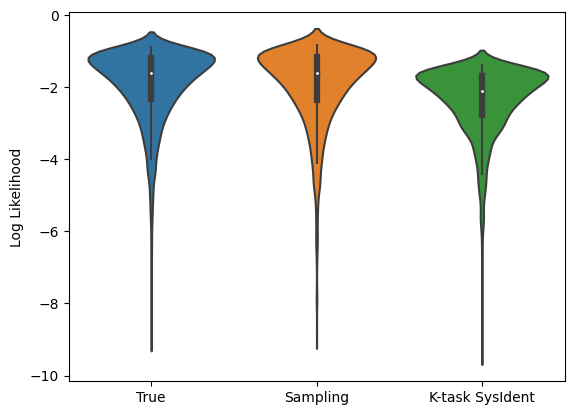

In [57]:
# draw a violin plot
fig, ax = plt.subplots(dpi=100)
sns.violinplot(data=[true_t2_ll_test, adapted_t2_ll_test, combined_sysident_ll_test], ax=ax)
ax.set_xticklabels(["True", "Sampling", "K-task SysIdent"])
ax.set_ylabel("Log Likelihood")
plt.show()

# Train sysident on k-different tasks

In [63]:
k = 100

In [76]:
k_task_mean = torch.zeros(n_neurons)
k_task_cov = torch.eye(n_neurons) * 5
k_task_mean_dist = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=k_task_mean, covariance_matrix=k_task_cov
)

/tmp/ipykernel_3430658/4230515135.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")
/tmp/ipykernel_3430658/4230515135.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, k_task_pdf, cmap="Greens", label="k-task")


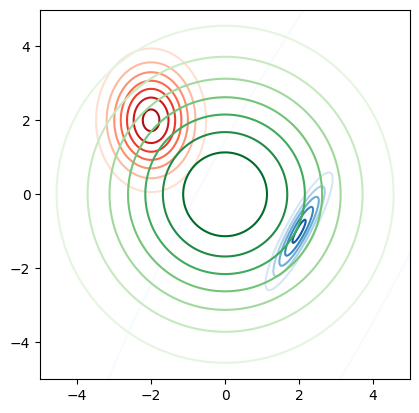

In [77]:
x, y = np.mgrid[-5:5:0.01, -5:5:0.01]
pos = np.dstack((x, y))

t1_pdf = t1_prior(torch.tensor(pos)).exp()
t2_pdf = t2_prior(torch.tensor(pos)).exp()
k_task_pdf = k_task_mean_dist(torch.tensor(pos)).exp()

fig, ax = plt.subplots(dpi=100)
ax.contour(x, y, t1_pdf, cmap="Blues")
ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")
ax.contour(x, y, k_task_pdf, cmap="Greens", label="k-task")
# make square
ax.set_aspect("equal", "box")

In [78]:
k_means = k_task_mean_dist.sample((k,))
k_covs = torch.eye(n_neurons).repeat(k, 1, 1)

In [79]:
k_means.shape, k_covs.shape

(torch.Size([100, 2]), torch.Size([100, 2, 2]))

In [80]:
k_dists = [G.TrainableDistributionAdapter(D.MultivariateNormal, loc=mean, covariance_matrix=cov) for mean, cov in zip(k_means, k_covs)]

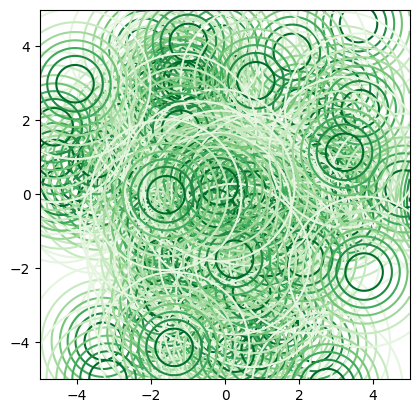

In [81]:
k_pds = [dist(torch.tensor(pos)).exp() for dist in k_dists]
# plot the k-task posteriors
fig, ax = plt.subplots(dpi=100)
for pd in k_pds:
    ax.contour(x, y, pd, cmap="Greens")
# make square
ax.set_aspect("equal", "box")

/tmp/ipykernel_3430658/2994409339.py:10: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")
/tmp/ipykernel_3430658/2994409339.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, k_task_pdf, cmap="Greens", label="k-task")


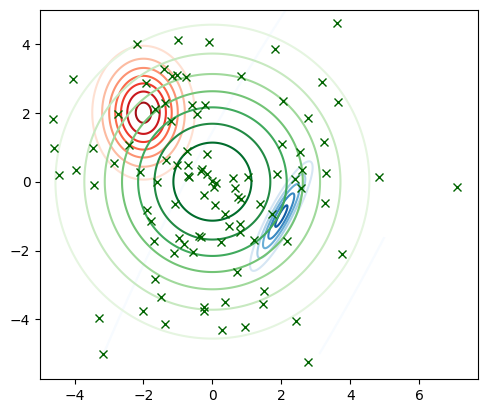

In [85]:
x, y = np.mgrid[-5:5:0.01, -5:5:0.01]
pos = np.dstack((x, y))

t1_pdf = t1_prior(torch.tensor(pos)).exp()
t2_pdf = t2_prior(torch.tensor(pos)).exp()
k_task_pdf = k_task_mean_dist(torch.tensor(pos)).exp()

fig, ax = plt.subplots(dpi=100)
ax.contour(x, y, t1_pdf, cmap="Blues")
ax.contour(x, y, t2_pdf, cmap="Reds", label="t2")
ax.contour(x, y, k_task_pdf, cmap="Greens", label="k-task")
ax.plot(k_means[:, 0], k_means[:, 1], "x", color="darkgreen")
# make square
ax.set_aspect("equal", "box")

In [98]:
dataset_size

10000

In [101]:
k_joints = [G.Joint(prior=k_dist, conditional=conditional) for k_dist in k_dists]
k_datasets = [k_joint.sample((dataset_size,)) for k_joint in k_joints]
print(len(k_datasets))

100


In [102]:
print(k_datasets[0][0].shape, k_datasets[0][1].shape)

torch.Size([10000, 2]) torch.Size([10000, 3])


Text(0, 0.5, 'Log Likelihood')

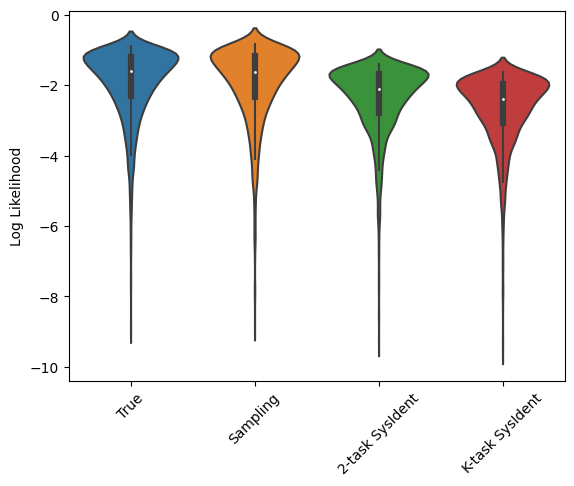

In [113]:
k_train_responses = [dataset[0][int(dataset_size * 0.8):] for dataset in k_datasets]
k_train_images = [dataset[1][int(dataset_size * 0.8):] for dataset in k_datasets]
k_test_responses = [dataset[0] for dataset in k_datasets]
k_combined_train_images = torch.cat(k_train_images)
k_combined_train_responses = torch.cat(k_train_responses)
# shuffle the combined dataset
shuffle_idx = rng.permutation(len(k_combined_train_images))
k_combined_train_images = k_combined_train_images[shuffle_idx]
k_combined_train_responses = k_combined_train_responses[shuffle_idx]
# train one sysident model on the combined dataset
k_combined_sysident_posterior = sysident_posterior(
    k_combined_train_responses, k_combined_train_images
)
# test the sysident model on the test dataset of task 2
with torch.no_grad():
    k_combined_sysident_ll_test = k_combined_sysident_posterior(
        t2_test_responses, cond=t2_test_images
    )
# plot the results along with performance of the true and adapted models
fig, ax = plt.subplots(dpi=100)
sns.violinplot(
    data=[true_t2_ll_test, adapted_t2_ll_test, combined_sysident_ll_test, k_combined_sysident_ll_test], ax=ax
)
ax.set_xticklabels(["True", "Sampling", "2-task SysIdent", "K-task SysIdent"], rotation=45)
ax.set_ylabel("Log Likelihood")

In [114]:
# plot the posterior densities of all models by picking a the mean image of task 2
mean_image = t2_test_images.mean(dim=0)
print(mean_image.shape)

torch.Size([3])


In [121]:
with torch.no_grad():
    true_t2_posterior_pdf_mean_image = true_t2_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp( )
    adapted_t2_posterior_pdf_mean_image = adapted_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
    combined_sysident_posterior_pdf_mean_image = combined_sysident_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
    k_combined_sysident_posterior_pdf_mean_image = k_combined_sysident_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()

/tmp/ipykernel_3430658/3904163929.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, adapted_t2_posterior_pdf_mean_image, cmap="Reds", label="t2")
/tmp/ipykernel_3430658/3904163929.py:4: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, combined_sysident_posterior_pdf_mean_image, cmap="Greens", label="k-task")
/tmp/ipykernel_3430658/3904163929.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, k_combined_sysident_posterior_pdf_mean_image, cmap="Purples", label="k-task")


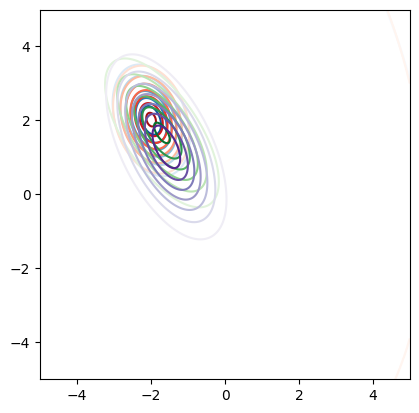

In [123]:
fig, ax = plt.subplots(dpi=100)
ax.contour(x, y, true_t2_posterior_pdf_mean_image, cmap="Blues")
ax.contour(x, y, adapted_t2_posterior_pdf_mean_image, cmap="Reds", label="t2")
ax.contour(x, y, combined_sysident_posterior_pdf_mean_image, cmap="Greens", label="k-task")
ax.contour(x, y, k_combined_sysident_posterior_pdf_mean_image, cmap="Purples", label="k-task")
# ax.plot(k_means[:, 0], k_means[:, 1], "x", color="darkgreen")
# make square
ax.set_aspect("equal", "box")

/tmp/ipykernel_3430658/1352853993.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, adapted_t2_posterior_pdf_another_image, cmap="Reds", label="t2")
/tmp/ipykernel_3430658/1352853993.py:18: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
/tmp/ipykernel_3430658/1352853993.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(


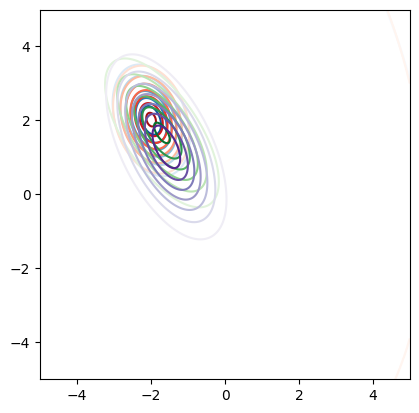

In [124]:
another_image = t2_test_images[0]
with torch.no_grad():
    true_t2_posterior_pdf_another_image = true_t2_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
    adapted_t2_posterior_pdf_another_image = adapted_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
    combined_sysident_posterior_pdf_another_image = combined_sysident_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
    k_combined_sysident_posterior_pdf_another_image = k_combined_sysident_posterior(
        torch.tensor(pos), cond=mean_image.unsqueeze(0)
    ).exp()
fig, ax = plt.subplots(dpi=100)
ax.contour(x, y, true_t2_posterior_pdf_another_image, cmap="Blues")
ax.contour(x, y, adapted_t2_posterior_pdf_another_image, cmap="Reds", label="t2")
ax.contour(
    x, y, combined_sysident_posterior_pdf_another_image, cmap="Greens", label="k-task"
)
ax.contour(
    x, y, k_combined_sysident_posterior_pdf_another_image, cmap="Purples", label="k-task"
)
# ax.plot(k_means[:, 0], k_means[:, 1], "x", color="darkgreen")
# make square
ax.set_aspect("equal", "box")